In [12]:
# load modules
%matplotlib inline
import matplotlib.pyplot as plt
# load general modules unrelated to jax
import os, sys

# set for jax on GPU, doesn't affect CPU
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' 

from glob import glob
import multiprocess
import numpy as np
from timeit import default_timer as timer

from astropy import constants as const
from astropy import units as u
from astropy.cosmology import Planck15, FlatLambdaCDM 
from functools import partial 

import seaborn as sns
from matplotlib.colors import LogNorm, SymLogNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


plt.rcParams['figure.dpi'] = 120
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True

# this requires a 50+ core CPU node or 1+ GPUs

due to the huge number of ODE solves across parameter perturbations for finite-diff Hessian

In [2]:
### read a basic config.yaml file and modify below
# it's easier to modify this existing dict than create config from scratch

from sapphire.utils import read_config

config = {'path_config':'/mnt/ceph/users/vpandya/sapphire/demo/pandya26/scripts/benchmark_runtime/config_benchmark.yaml'}

### read config based on user input
config = read_config.get(config,verbose=True) 

reading /mnt/ceph/users/vpandya/sapphire/demo/pandya26/scripts/benchmark_runtime/config_benchmark.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 10,
                            'adam_logL': 'manual',
                            'engine': 'adam',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': False,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_nam

In [4]:
### now run sapphire with runtype=finitediff
import sapphire

config['runtype'] = 'finitediff'

config,halo_index,halo_matrix,batch_solve8,batch_solve12 = sapphire.run(config)

reading /mnt/ceph/users/vpandya/sapphire/demo/pandya26/scripts/benchmark_runtime/config_benchmark.yaml

your full sapphire config:

{   'Nbatch': 1000,
    'chain_num': 0,
    'clip_etaE_max': 1.0,
    'coolfunc': 'sd93',
    'data_path': '/mnt/ceph/users/vpandya/sapphire/data/',
    'flag_fgas': 1,
    'flag_mzr': 0,
    'flag_mzr_gas': 1,
    'flag_sfms': 0,
    'flag_smhm': 1,
    'inference_config': {   'Nadam': 10,
                            'adam_logL': 'manual',
                            'engine': 'adam',
                            'fit_mock': False,
                            'fit_obs': True,
                            'num_samples': 1000,
                            'num_warmup': 1000,
                            'random_mock': False,
                            'write_output': True},
    'mock_err_fgas': 0.0,
    'mock_err_mzr': 0.0,
    'mock_err_mzr_gas': 0.0,
    'mock_err_sfms': 0.0,
    'mock_err_smhm': 0.0,
    'model': 'pandya23',
    'num_cpus': 50,
    'obs_nam

In [5]:
### now call utils/finitediff_gradients.hessians module
### this can take ~45 minutes for Nsamples=10

from sapphire.utils import finitediff_gradients

### initial parameter set will take longer since it has to jit-compile
# in general autodiff is 5-10x faster than finite-diff at fixed tol_ode and theta
dict_hess = finitediff_gradients.hessians(config,halo_index,batch_solve8,batch_solve12,Nsamples=10)

lower_bounds [-2. -4. -2. -4.  0. -4. -2. -4.]
upper_bounds [1.  0.  0.  0.  1.1 0.  0.  0. ]
full_params_arr.shape
 (10, 17)
latin hypercube param shapes (10, 17) (10, 8)
-----> working on 0
remade mock stats and loss func in 9.056 sec
ad8 finished in 15.796 sec
ad12 finished in 31.122 sec
fd8 finished in 211.414 sec
fd12 finished in 341.555 sec
-----> working on 1
remade mock stats and loss func in 1.978 sec
ad8 finished in 4.420 sec
ad12 finished in 16.564 sec
fd8 finished in 42.024 sec
fd12 finished in 139.790 sec
-----> working on 2
remade mock stats and loss func in 1.991 sec
ad8 finished in 4.635 sec
ad12 finished in 17.096 sec
fd8 finished in 44.006 sec
fd12 finished in 143.742 sec
-----> working on 3
remade mock stats and loss func in 1.995 sec
ad8 finished in 4.326 sec
ad12 finished in 17.204 sec
fd8 finished in 41.164 sec
fd12 finished in 143.501 sec
-----> working on 4
remade mock stats and loss func in 1.895 sec
ad8 finished in 4.218 sec
ad12 finished in 15.408 sec
fd8 fin

In [10]:
### since it's so expensive, can just save it once here for later plotting purposes 

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 
# jax_config.update('jax_num_cpu_devices', 48) # jax doesn't auto-detect multi-cpus

import jax
import jax.numpy as jnp

jnp.savez('/mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_hessians.npz',
          dict_hess = dict_hess,
          allow_pickle=True)

In [11]:
### this is large so actually I will not include it in sapphire_data github tarball, but will include on Zenodo 
!ls -lah /mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_hessians.npz

-rw------- 1 vpandya vpandya 41K Aug 10 21:02 /mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_hessians.npz


# if you just want to plot, re-read the saved data here

In [1]:
import os, sys
# set for jax on GPU, doesn't affect CPU
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false' 

# in case user loads module separately from sapphire.run()
from jax import config as jax_config
jax_config.update("jax_enable_x64", True) # required to accurately solve and take gradients through our diffeqs 
# jax_config.update('jax_num_cpu_devices', 48) # jax doesn't auto-detect multi-cpus

import jax
import jax.numpy as jnp

In [3]:
npz_hess = jnp.load('/mnt/ceph/users/vpandya/sapphire_outputs/outputs/finitediff_hessians.npz',allow_pickle=True)

out_hess = npz_hess['dict_hess'].item()

out_hess.keys()

dict_keys(['params_free', 'full_params_arr', 'free_params_arr', 'arr_hessians_ad8', 'arr_hessians_ad12', 'arr_hessians_fd8', 'arr_hessians_fd12', 'err_hessians_ad', 'err_hessians_fd8', 'err_hessians_fd12', 'median_ad_err', 'median_fd8_err', 'median_fd12_err', 'norm_ad_err', 'norm_fd8_err', 'norm_fd12_err'])

# Figure 23 of Pandya+26

In [14]:
median_fd8_err = out_hess['median_fd8_err']
median_fd12_err = out_hess['median_fd12_err']
median_ad_err = out_hess['median_ad_err']

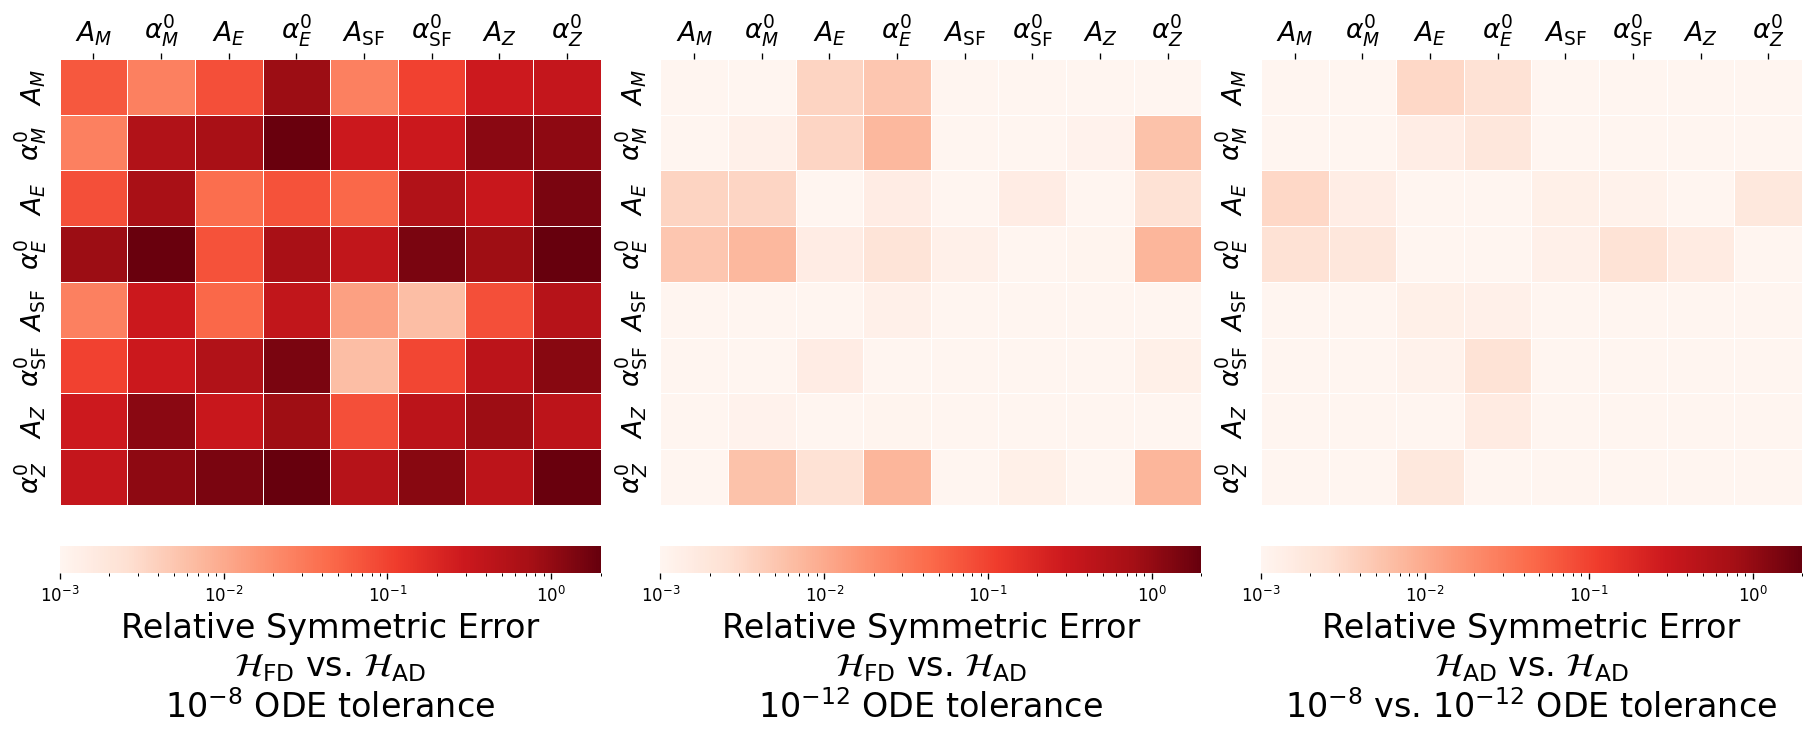

In [15]:
Hax_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',
              r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']

# cmap = sns.color_palette("vlag_r", as_cmap=True)
# cmap_norm = SymLogNorm(vmin=-2, vmax=2, linthresh=1e-2)
cmap = sns.color_palette("Reds", as_cmap=True)
cmap_norm = LogNorm(vmin=1e-3,vmax=2.0)
cbar_kws = {'orientation': 'horizontal', 'pad': 0.08}

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(15,6),constrained_layout=True)

sns.heatmap(median_fd8_err, linewidths=.5, ax=axes[0], annot=False, fmt=".1e", 
            cmap=cmap,norm=cmap_norm,cbar_kws=cbar_kws,
            yticklabels=Hax_labels,xticklabels=Hax_labels,)

sns.heatmap(median_fd12_err, linewidths=.5, ax=axes[1], annot=False, fmt=".1e", 
            cmap=cmap,norm=cmap_norm,cbar_kws=cbar_kws,
            yticklabels=Hax_labels,xticklabels=Hax_labels)

sns.heatmap(median_ad_err, linewidths=.5, ax=axes[2], annot=False, fmt=".1e", 
            cmap=cmap,norm=cmap_norm,cbar_kws=cbar_kws,
            yticklabels=Hax_labels,xticklabels=Hax_labels)

# colorbar labels 
axes[0].collections[0].colorbar.set_label('Relative Symmetric Error\n'+r'$\mathcal{H}_{\rm FD}$ vs. $\mathcal{H}_{\rm AD}$'+'\n'+r'$10^{-8}$ ODE tolerance',
                                          fontsize=20)
axes[1].collections[0].colorbar.set_label('Relative Symmetric Error\n'+r'$\mathcal{H}_{\rm FD}$ vs. $\mathcal{H}_{\rm AD}$'+'\n'+r'$10^{-12}$ ODE tolerance',
                                          fontsize=20)
axes[2].collections[0].colorbar.set_label('Relative Symmetric Error\n'+r'$\mathcal{H}_{\rm AD}$ vs. $\mathcal{H}_{\rm AD}$'+'\n'+r'$10^{-8}$ vs. $10^{-12}$ ODE tolerance',
                                          fontsize=20)

for ax in axes:
    
    ax.tick_params(axis='both',which='both',left=False,right=False,top=False,bottom=False)
    ax.set_xticklabels(Hax_labels,fontsize=16)
    ax.set_yticklabels(Hax_labels,fontsize=16)
    
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# plt.savefig('finitediff_hessians.png',bbox_inches='tight',dpi=300,facecolor='w')

# additional exploratory plots (not in paper)

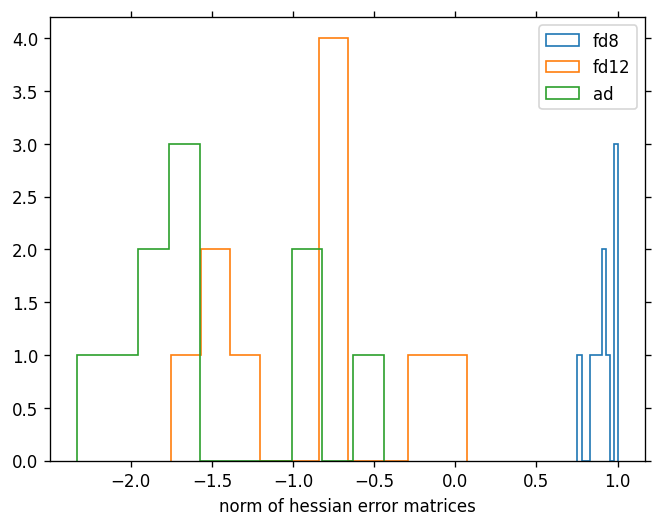

In [17]:
# norms of autodiff hessian error matrices tend to be less than fd12, both are much better than fd8

norm_fd8_err = out_hess['norm_fd8_err']
norm_fd12_err = out_hess['norm_fd12_err']
norm_ad_err = out_hess['norm_ad_err']

_ = plt.hist(jnp.log10(norm_fd8_err),histtype='step',label='fd8')
_ = plt.hist(jnp.log10(norm_fd12_err),histtype='step',label='fd12')
_ = plt.hist(jnp.log10(norm_ad_err),histtype='step',label='ad')

plt.xlabel('norm of hessian error matrices')

plt.legend()

In [22]:
"""
for single parameter, show sequence of corner plots demonstrating efficiency and accuracy of autodiff hessians 

"""

from chainconsumer import Chain, ChainConsumer, make_sample, PlotConfig, Truth

### pick random parameter
pindex = 0

plt_params = out_hess['free_params_arr'][pindex]
hess_ad8 = out_hess['arr_hessians_ad8'][pindex]
hess_ad12 = out_hess['arr_hessians_ad12'][pindex]
hess_fd8 = out_hess['arr_hessians_fd8'][pindex]
hess_fd12 = out_hess['arr_hessians_fd12'][pindex]
params_free = out_hess['params_free']


/mnt/home/vpandya/miniconda3/envs/japphiregpu/lib/python3.12/site-packages/chainconsumer/chain.py:326: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  samples = rng.multivariate_normal(mean, covariance, size=1000000)  # type: ignore


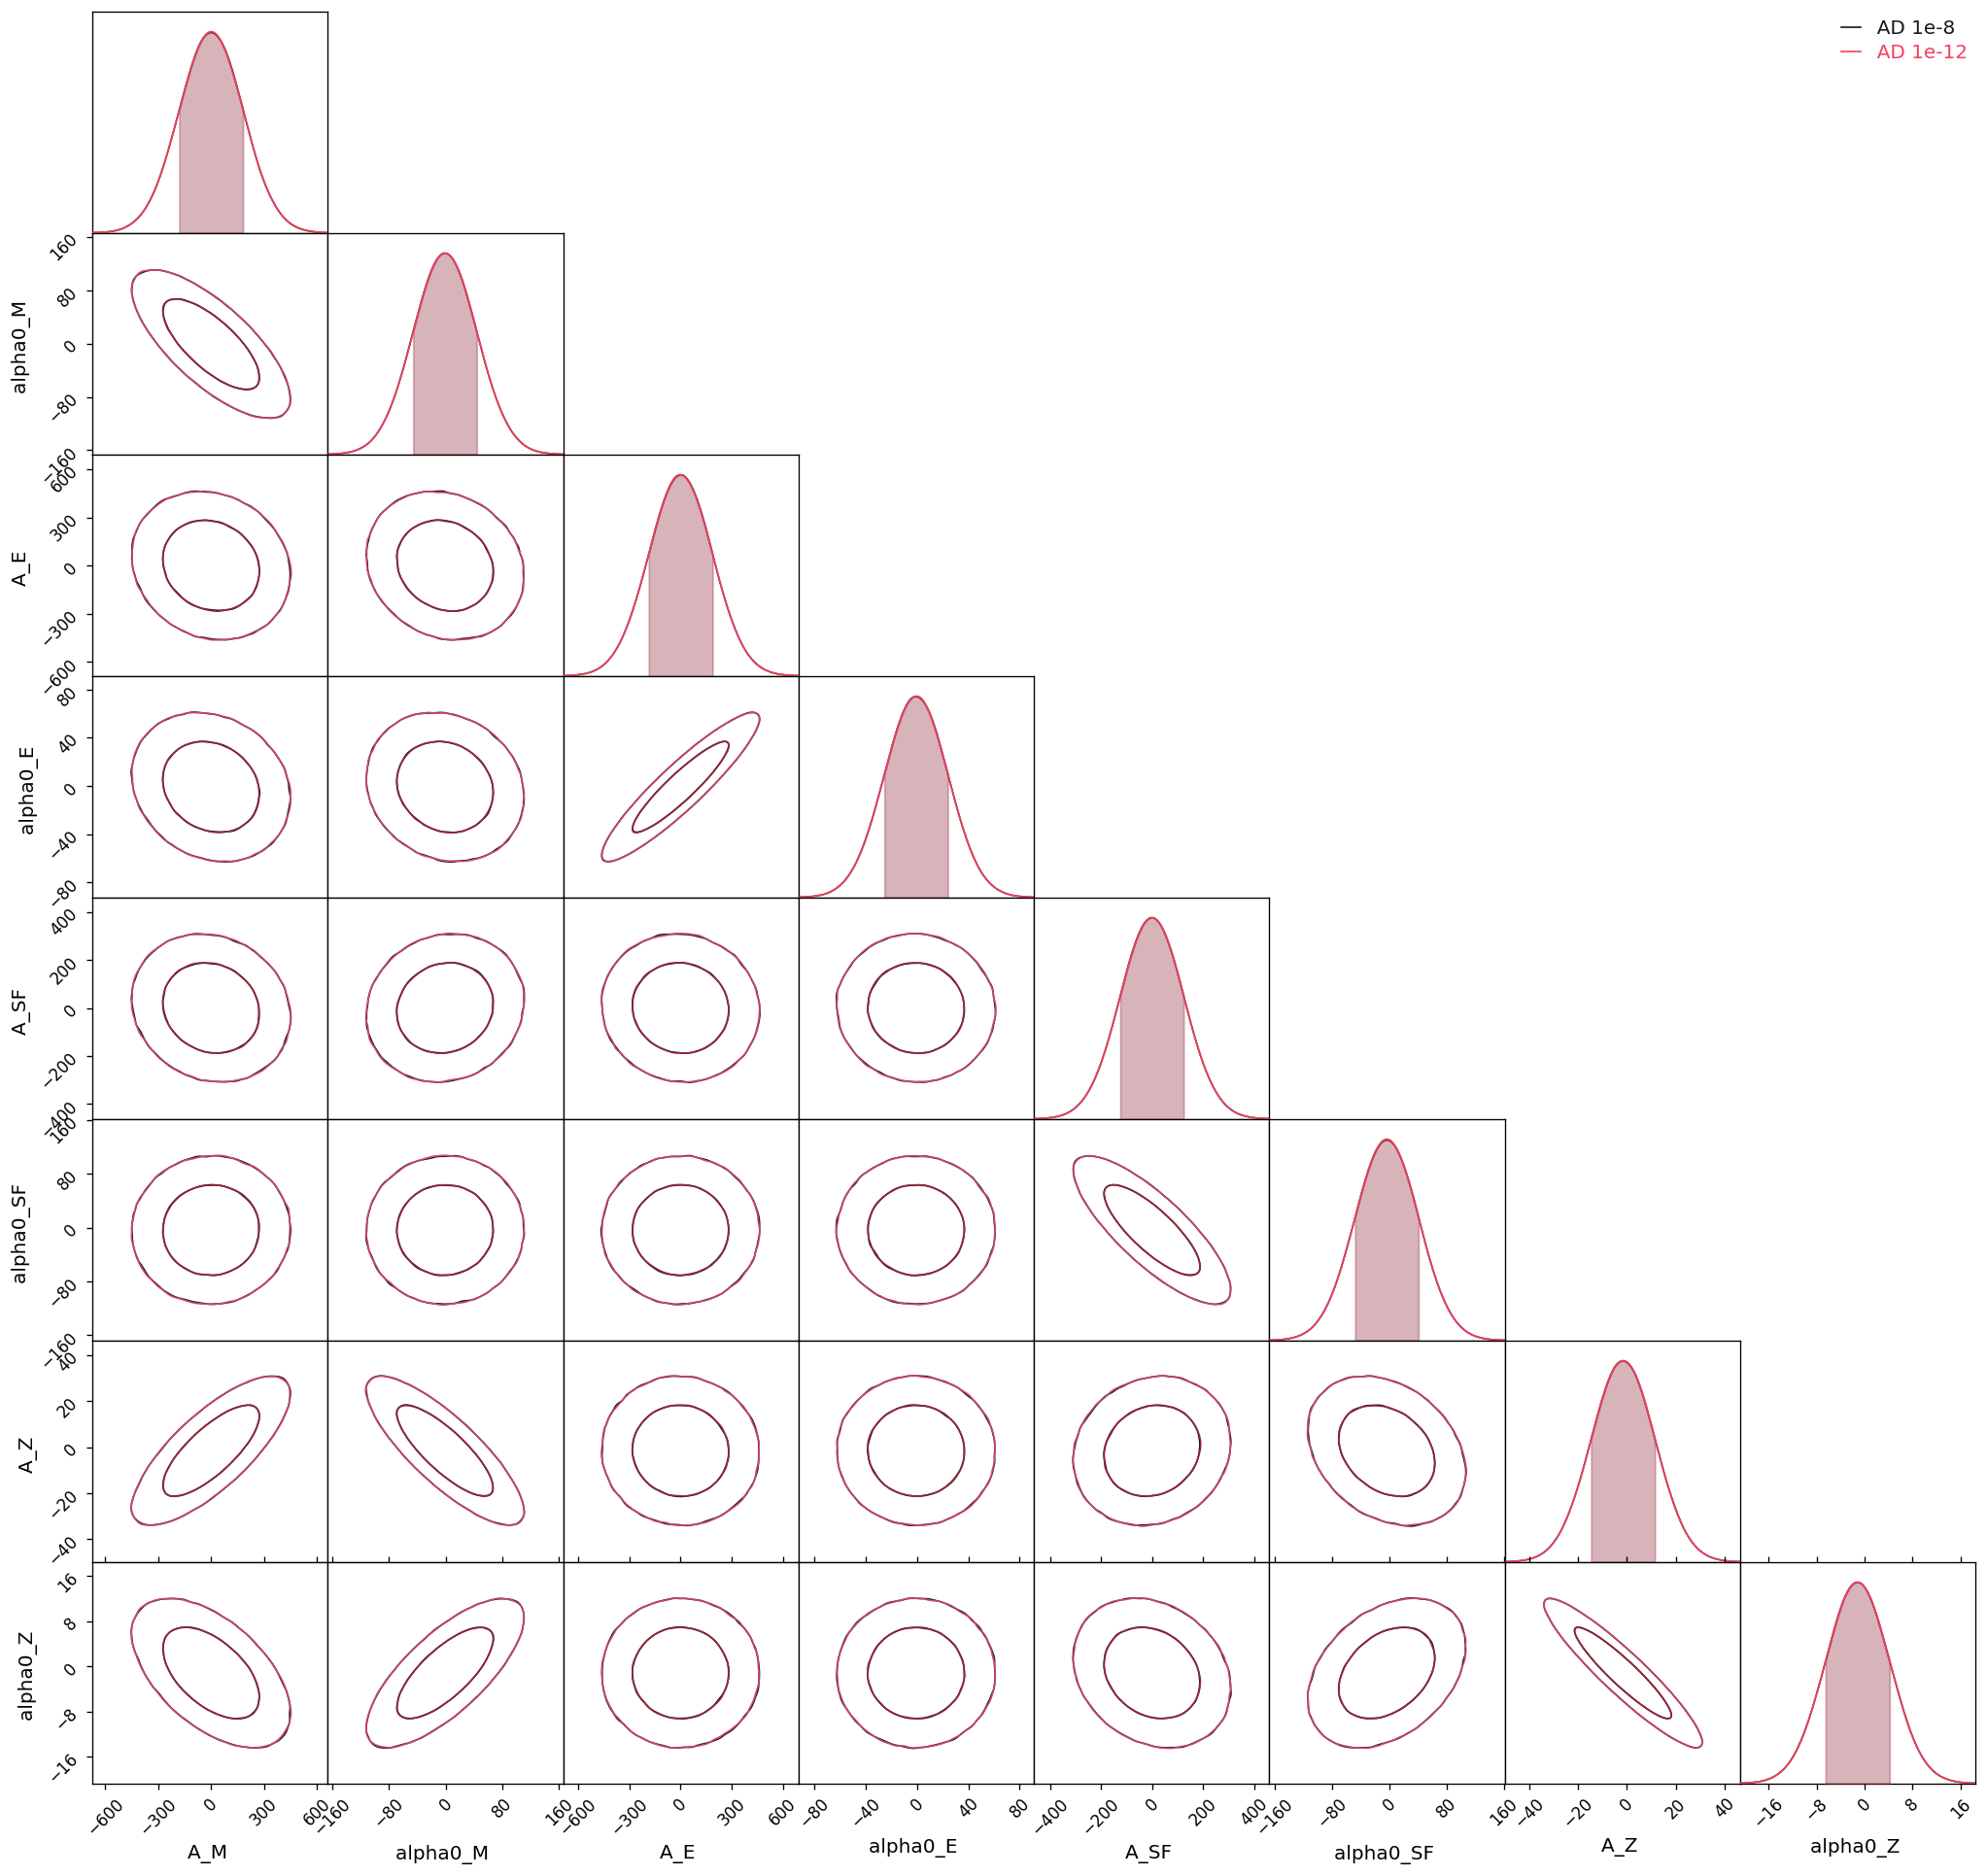

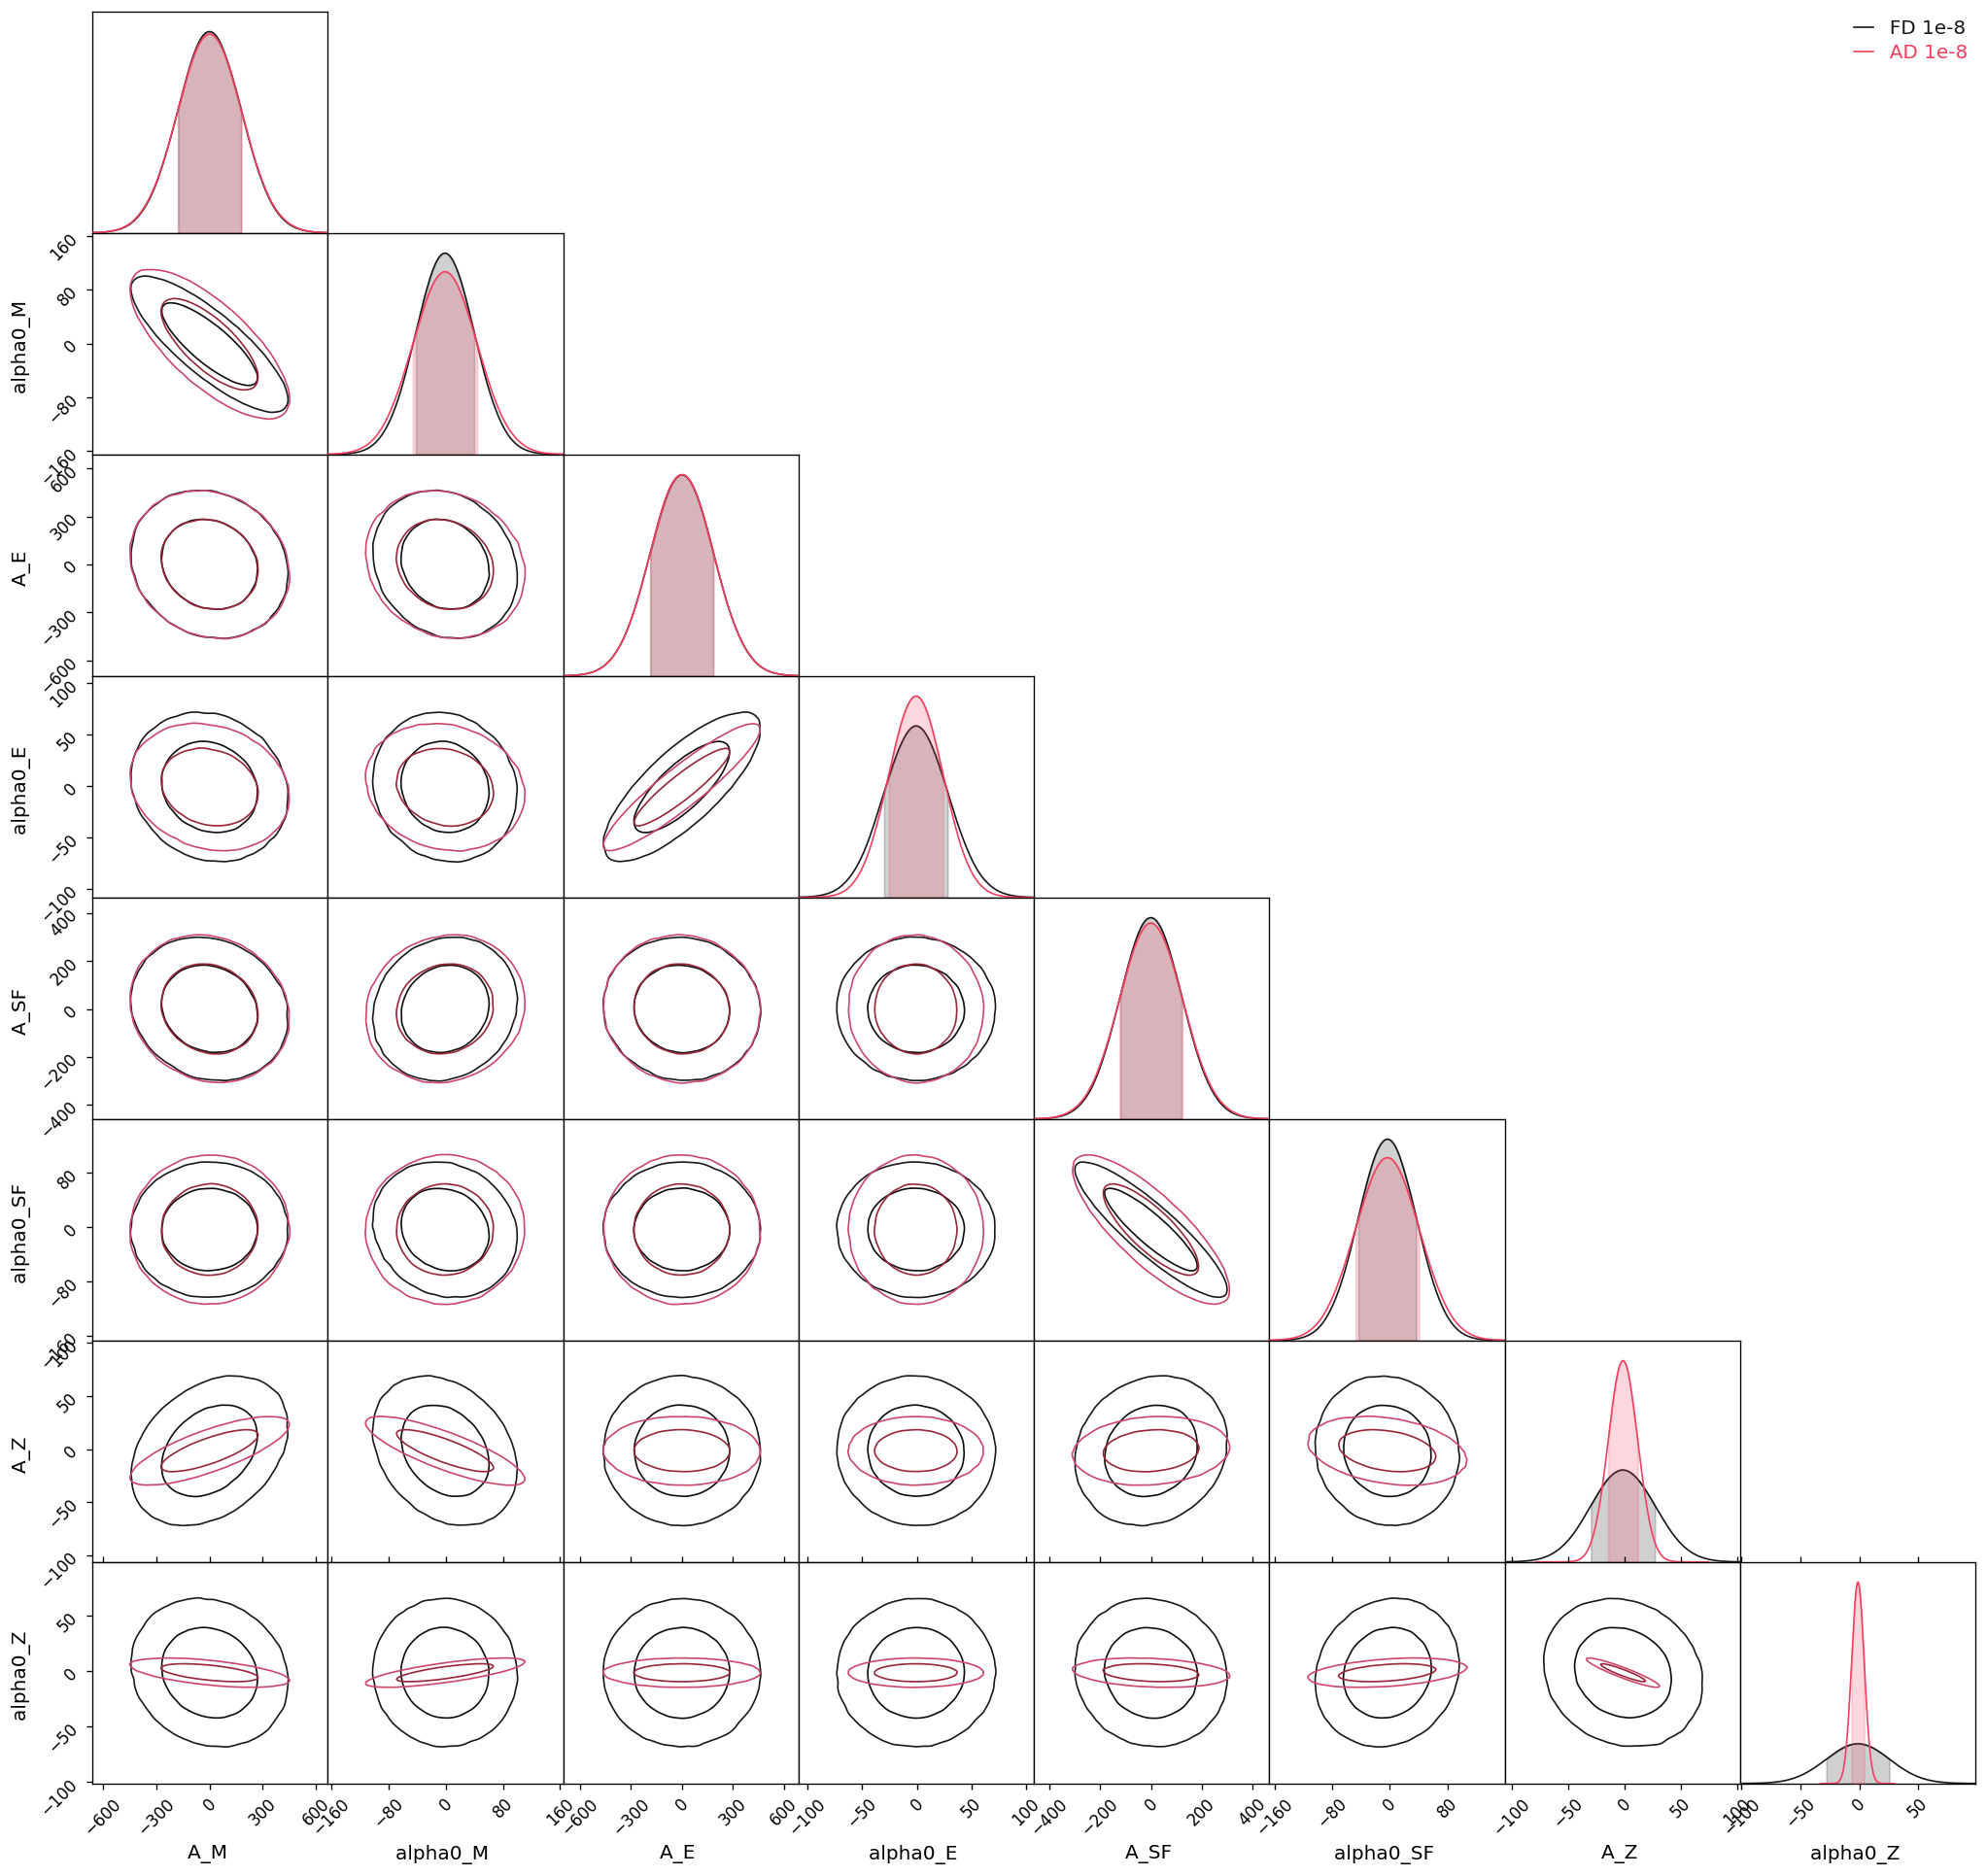

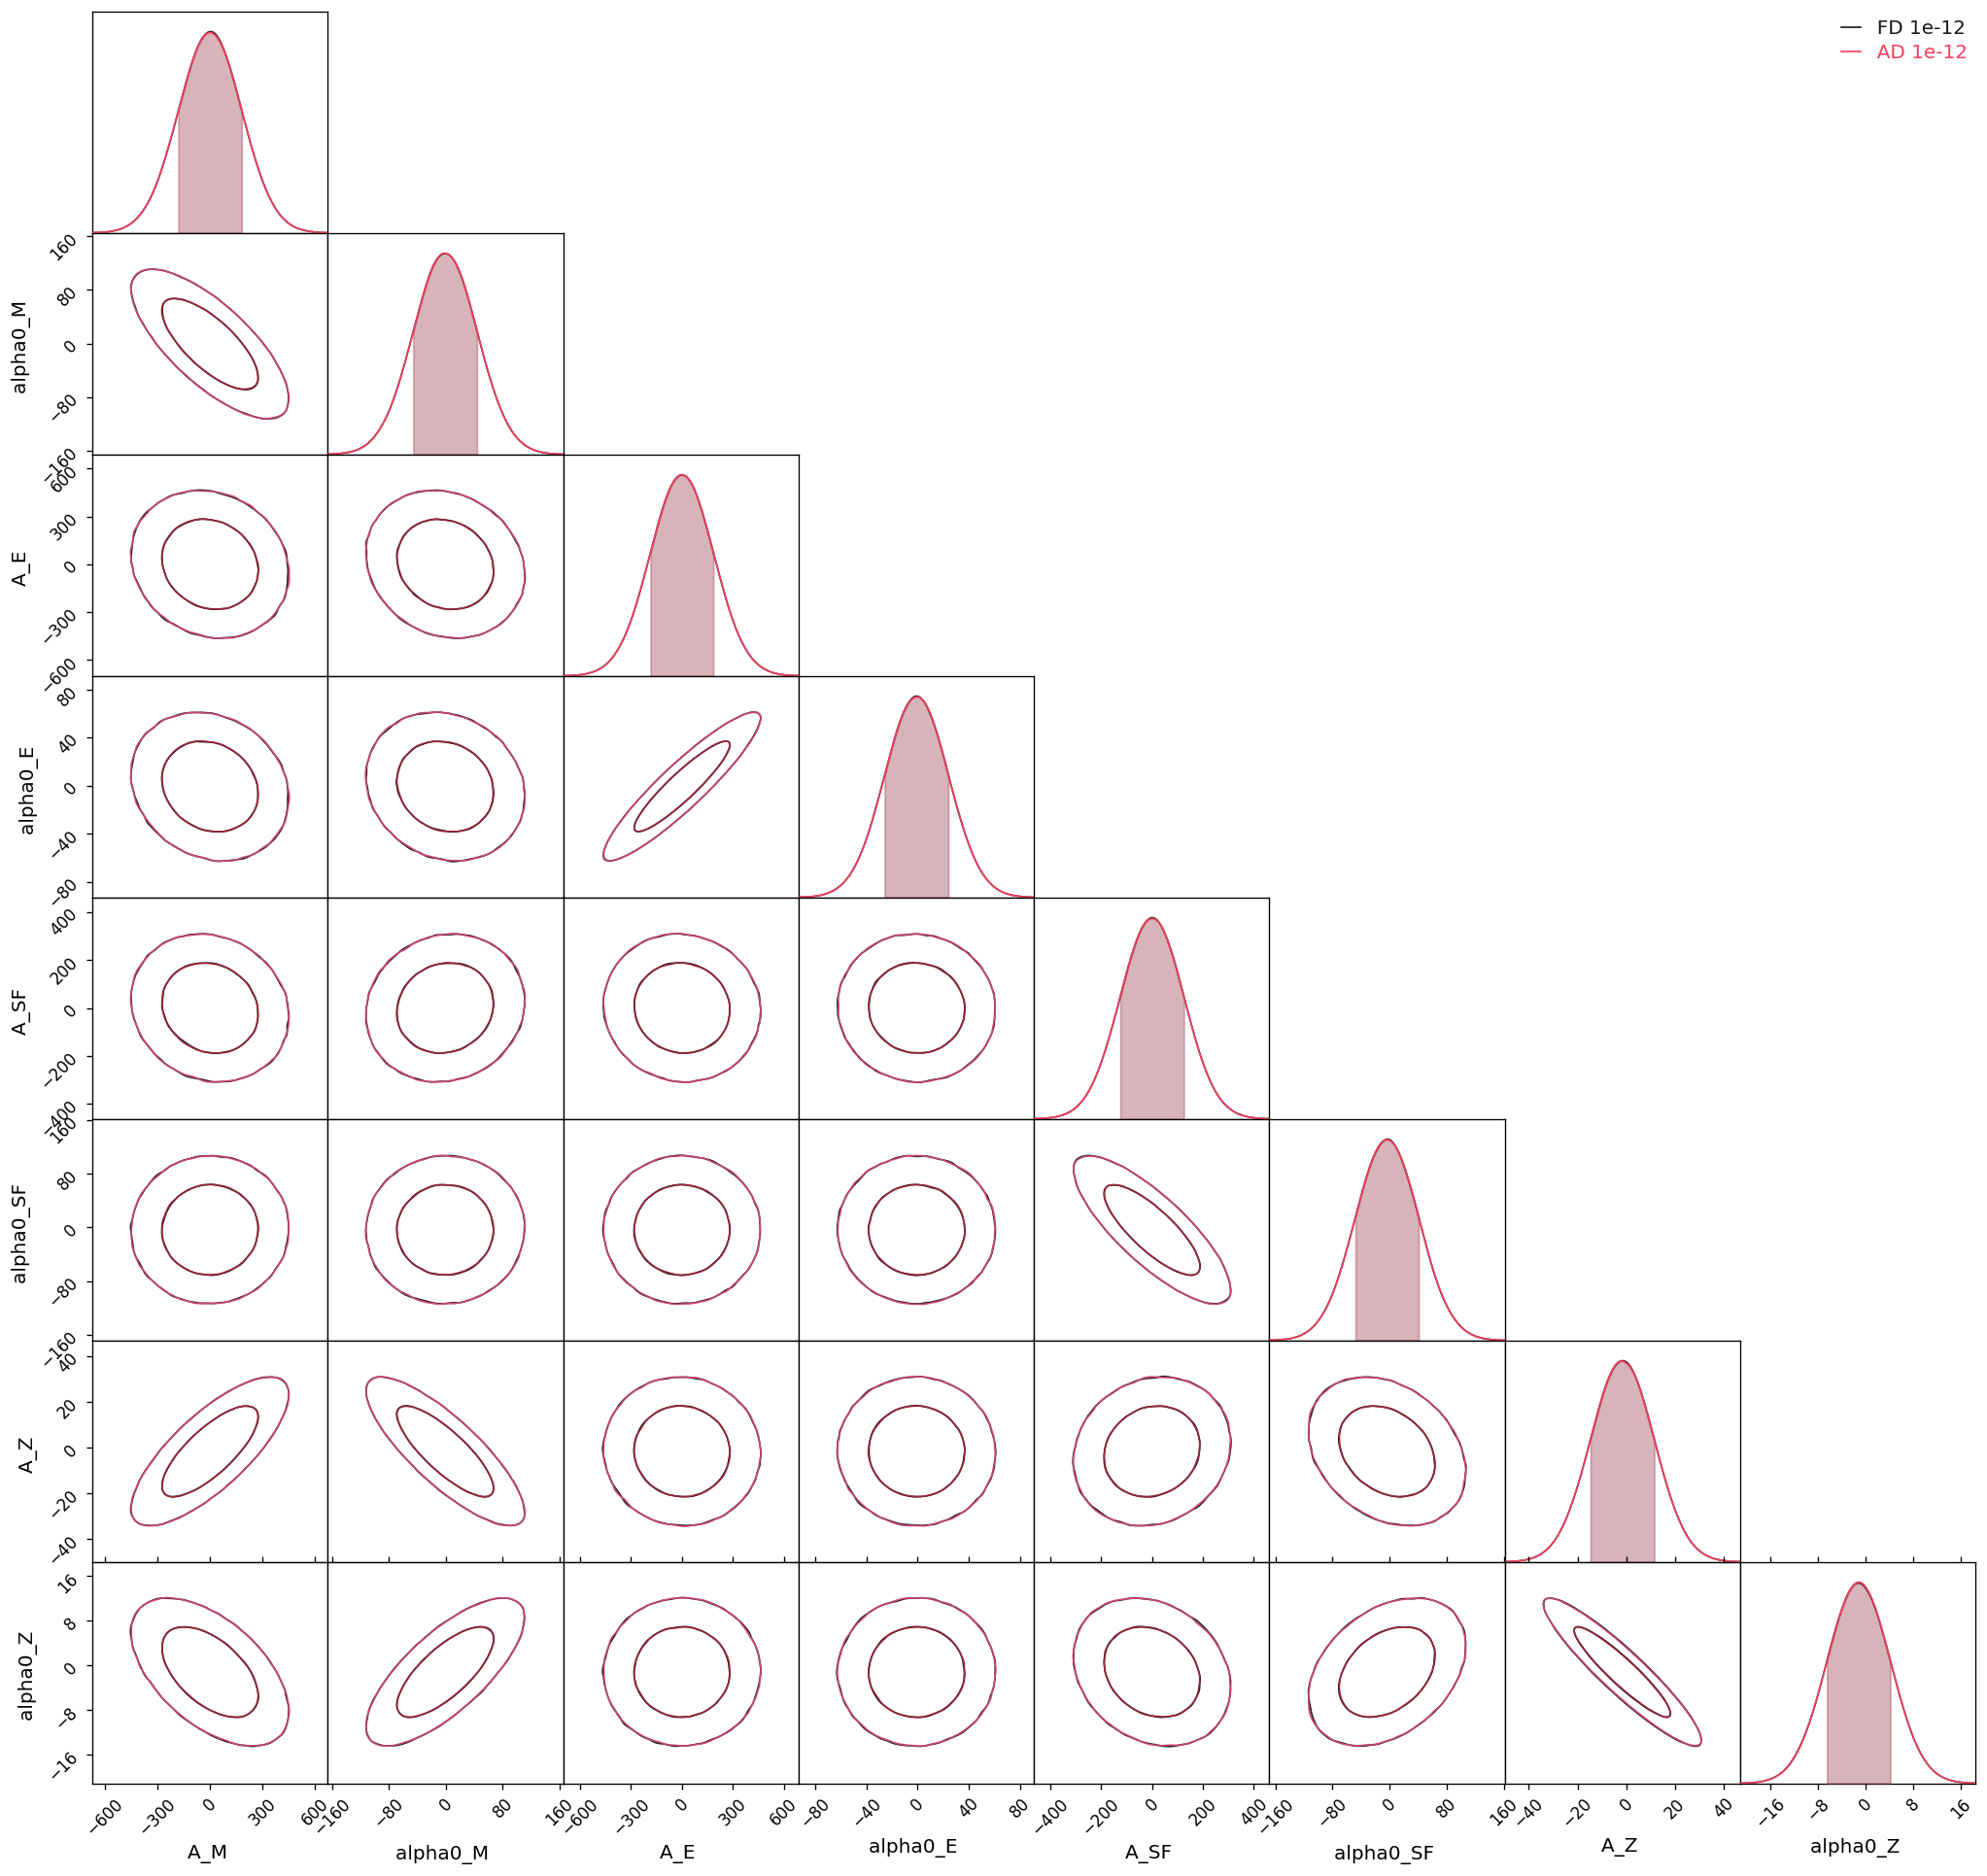

In [28]:
# first, importantly AD 1e-8 vs 1e-12 tolerance agree with each other
c1 = ChainConsumer()
chain1 = Chain.from_covariance(plt_params,hess_ad8,columns=params_free,name='AD 1e-8',shade=False,color='k')
chain2 = Chain.from_covariance(plt_params,hess_ad12,columns=params_free,name='AD 1e-12',shade=False,color='m')
c1.add_chain(chain1)
c1.add_chain(chain2)
fig1 = c1.plotter.plot(figsize="column") 

# however, finite-diff 1e-8 disagrees with ad 1e-8 (but we know ad 1e-8 agrees w/ higher accuracy "truth" ad 1e-12 solution)
c2 = ChainConsumer()
chain1 = Chain.from_covariance(plt_params,hess_fd8,columns=params_free,name='FD 1e-8',shade=False,color='k')
chain2 = Chain.from_covariance(plt_params,hess_ad8,columns=params_free,name='AD 1e-8',shade=False,color='m')
c2.add_chain(chain1)
c2.add_chain(chain2)
fig2 = c2.plotter.plot() 

# but finite-diff 1e-12 agrees with ad 1e-12, meaning fd hessians would need tighter, more expensive tolerances
c3 = ChainConsumer()
chain1 = Chain.from_covariance(plt_params,hess_fd12,columns=params_free,name='FD 1e-12',shade=False,color='k')
chain2 = Chain.from_covariance(plt_params,hess_ad12,columns=params_free,name='AD 1e-12',shade=False,color='m')
c3.add_chain(chain1)
c3.add_chain(chain2)
fig3 = c3.plotter.plot() 


In [16]:
""" 
even though the fd12 and ad12 hessians agree, 
the apparently small errors will get amplified 
when we invert the hessians to get fisher matrices

autodiff wins -- and it shows self-consistency of the solution + second-order gradients
""" 

arr_hessians_ad8 = out_hess['arr_hessians_ad8']
arr_hessians_ad12 = out_hess['arr_hessians_ad12']
arr_hessians_fd8 = out_hess['arr_hessians_fd8']
arr_hessians_fd12 = out_hess['arr_hessians_fd12']

arr_fishers_ad8 = jnp.linalg.inv(arr_hessians_ad8)
arr_fishers_ad12 = jnp.linalg.inv(arr_hessians_ad12)
arr_fishers_fd8 = jnp.linalg.inv(arr_hessians_fd8)
arr_fishers_fd12 = jnp.linalg.inv(arr_hessians_fd12)

err_fishers_ad = jnp.abs((arr_fishers_ad8 - arr_fishers_ad12)/(0.5*(jnp.abs(arr_fishers_ad8)+jnp.abs(arr_fishers_ad12))))
err_fishers_fd8 = jnp.abs((arr_fishers_fd8 - arr_fishers_ad8)/(0.5*(jnp.abs(arr_fishers_fd8)+jnp.abs(arr_fishers_ad8))))
err_fishers_fd12 = jnp.abs((arr_fishers_fd12 - arr_fishers_ad12)/(0.5*(jnp.abs(arr_fishers_fd12)+jnp.abs(arr_fishers_ad12))))

print('err_fishers_ad.shape, err_fishers_fd8.shape, err_fishers_fd12.shape',
      err_fishers_ad.shape, err_fishers_fd8.shape, err_fishers_fd12.shape,flush=True)

### compute median (across parameter realizations) of absolute value of relative symmetric error (like a fractional error) 

median_fisher_ad_err = jnp.median(err_fishers_ad,axis=0)
median_fisher_fd8_err = jnp.median(err_fishers_fd8,axis=0)
median_fisher_fd12_err = jnp.median(err_fishers_fd12,axis=0)


err_fishers_ad.shape, err_fishers_fd8.shape, err_fishers_fd12.shape (10, 8, 8) (10, 8, 8) (10, 8, 8)


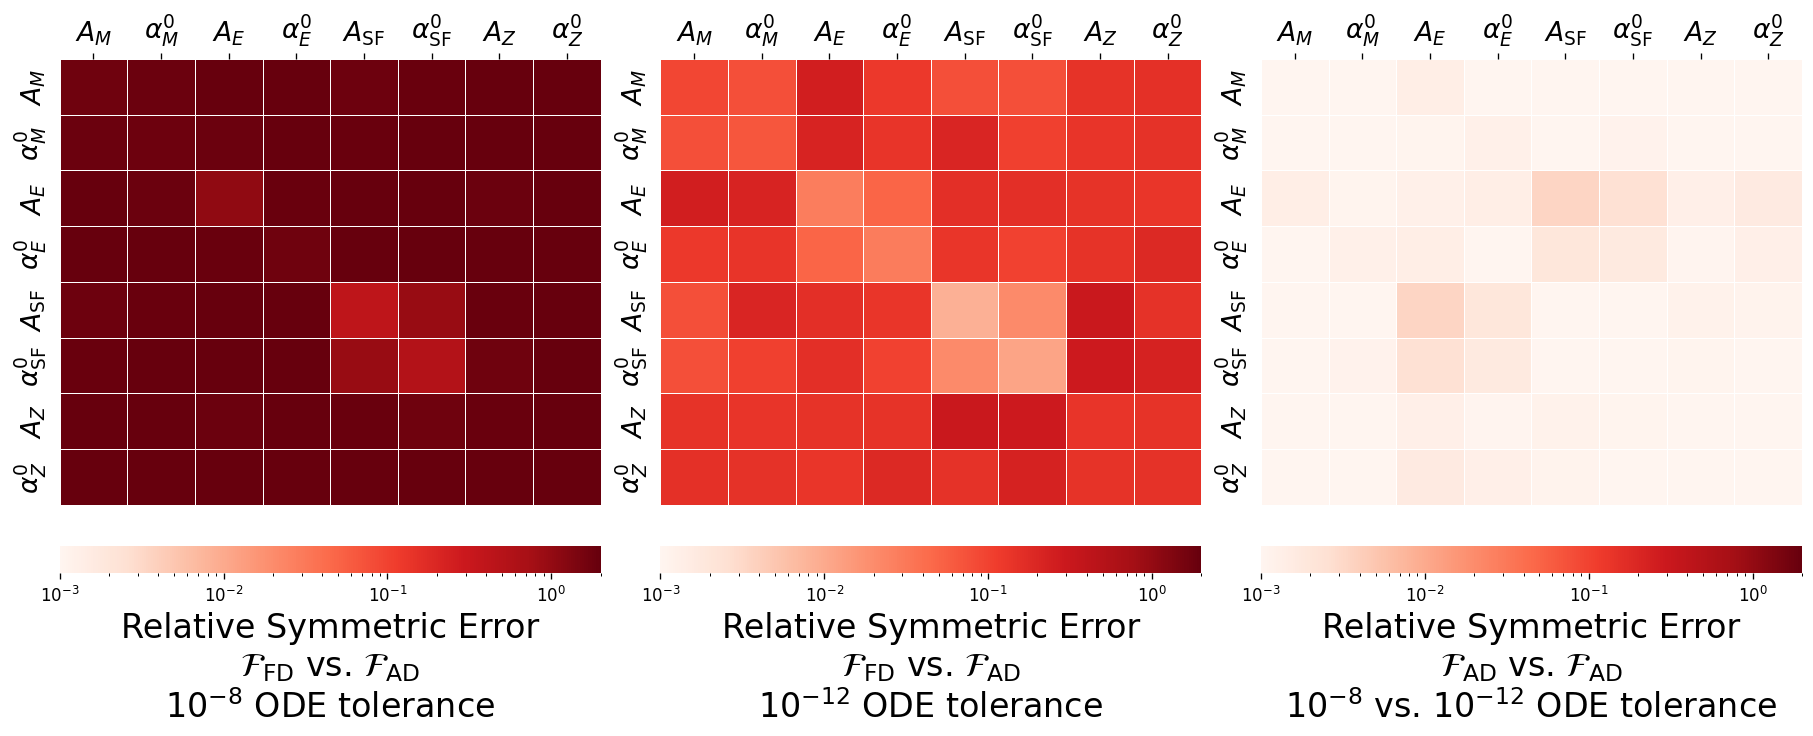

In [18]:
Hax_labels = [r'$A_M$',r'$\alpha_M^0$',r'$A_E$',r'$\alpha_E^0$',
              r'$A_{\rm SF}$',r'$\alpha_{\rm SF}^0$',r'$A_Z$',r'$\alpha_Z^0$']

# cmap = sns.color_palette("vlag_r", as_cmap=True)
# cmap_norm = SymLogNorm(vmin=-2, vmax=2, linthresh=1e-2)
cmap = sns.color_palette("Reds", as_cmap=True)
cmap_norm = LogNorm(vmin=1e-3,vmax=2.0)
cbar_kws = {'orientation': 'horizontal', 'pad': 0.08}

fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(15,6),constrained_layout=True)

sns.heatmap(median_fisher_fd8_err, linewidths=.5, ax=axes[0], annot=False, fmt=".1e", 
            cmap=cmap,norm=cmap_norm,cbar_kws=cbar_kws,
            yticklabels=Hax_labels,xticklabels=Hax_labels,)

sns.heatmap(median_fisher_fd12_err, linewidths=.5, ax=axes[1], annot=False, fmt=".1e", 
            cmap=cmap,norm=cmap_norm,cbar_kws=cbar_kws,
            yticklabels=Hax_labels,xticklabels=Hax_labels)

sns.heatmap(median_fisher_ad_err, linewidths=.5, ax=axes[2], annot=False, fmt=".1e", 
            cmap=cmap,norm=cmap_norm,cbar_kws=cbar_kws,
            yticklabels=Hax_labels,xticklabels=Hax_labels)

# colorbar labels 
axes[0].collections[0].colorbar.set_label('Relative Symmetric Error\n'+r'$\mathcal{F}_{\rm FD}$ vs. $\mathcal{F}_{\rm AD}$'+'\n'+r'$10^{-8}$ ODE tolerance',
                                          fontsize=20)
axes[1].collections[0].colorbar.set_label('Relative Symmetric Error\n'+r'$\mathcal{F}_{\rm FD}$ vs. $\mathcal{F}_{\rm AD}$'+'\n'+r'$10^{-12}$ ODE tolerance',
                                          fontsize=20)
axes[2].collections[0].colorbar.set_label('Relative Symmetric Error\n'+r'$\mathcal{F}_{\rm AD}$ vs. $\mathcal{F}_{\rm AD}$'+'\n'+r'$10^{-8}$ vs. $10^{-12}$ ODE tolerance',
                                          fontsize=20)

for ax in axes:
    
    ax.tick_params(axis='both',which='both',left=False,right=False,top=False,bottom=False)
    ax.set_xticklabels(Hax_labels,fontsize=16)
    ax.set_yticklabels(Hax_labels,fontsize=16)
    
    ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)

# plt.savefig('finitediff_hessians.png',bbox_inches='tight',dpi=300,facecolor='w')